In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data loading

In [2]:
sns.set_theme(style="whitegrid")

df = pd.read_csv('../data/Churn_Modelling.csv')
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

# 2. Data overview

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## Nhận xét:
- Dataset có 10,000 dòng, không có missing values
- Bao gồm:
    - Numerical features (int, float)
    - Categorical features (object)
- Target: `Exited`

## Phân loại feature
- Category:
    - Nominal: Geography, Gender
    - Binary: HasCrCard, IsActiveMember
- Numeric: 
    - Continuous: CreditScore, Age, Balance, EstimatedSalary
    - Discrete: Tenure, NumOfProducts


# 3. Data cleaning

## 3.1. Missing value

In [6]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## Nhận xét:
- Không có giá trị thiếu, không cần xử lý

## 3.2. Duplicate

In [7]:
df.duplicated().sum()

np.int64(0)

## Nhận xét:
- Không có giá trị trùng lập, không cần xử lý

## 3.3. Drop cột không cần thiết

In [8]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

## Nhận xét:
- `RowNumber`: chỉ là chỉ số thứ tự → không mang ý nghĩa trong mô hình
- `CustomerId`: định danh khách hàng → không có giá trị dự đoán
- `Surname`: dữ liệu dạng text, không phản ánh hành vi churn

→ Các cột này được loại bỏ để tránh gây nhiễu cho mô hình

# 4. Feature classification

In [9]:
num_cols = ["CreditScore", "Age", "Balance", "EstimatedSalary"]
disc_cols = ["Tenure", "NumOfProducts"]
cat_cols = ["Geography", "Gender"]
bin_cols = ["HasCrCard", "IsActiveMember"]
target = "Exited"

# 5. Univariate Analysis

## 5.1. Numerical feature

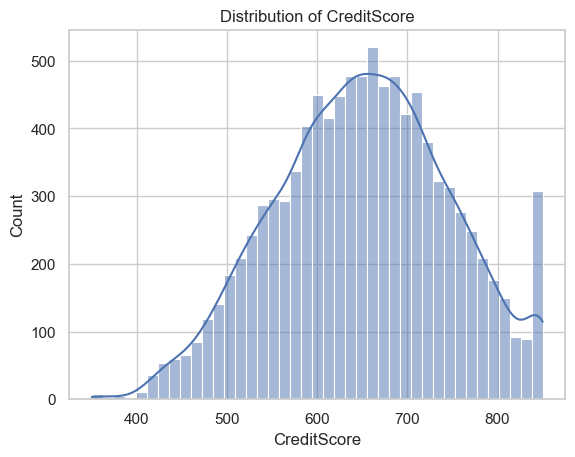

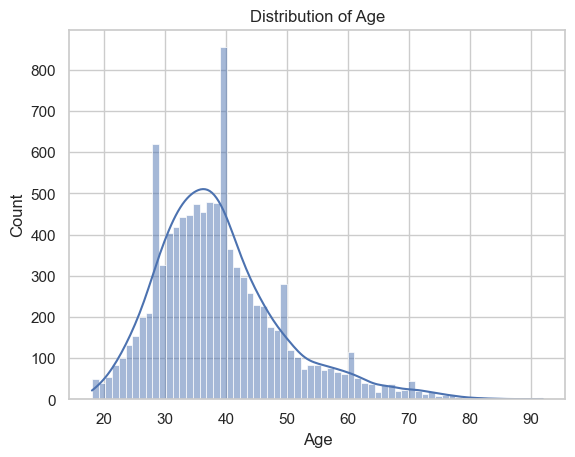

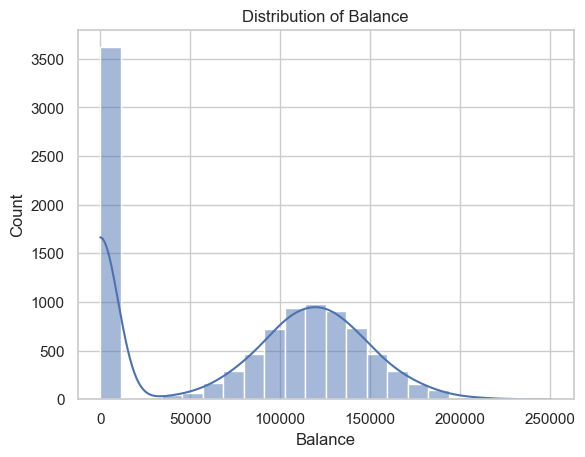

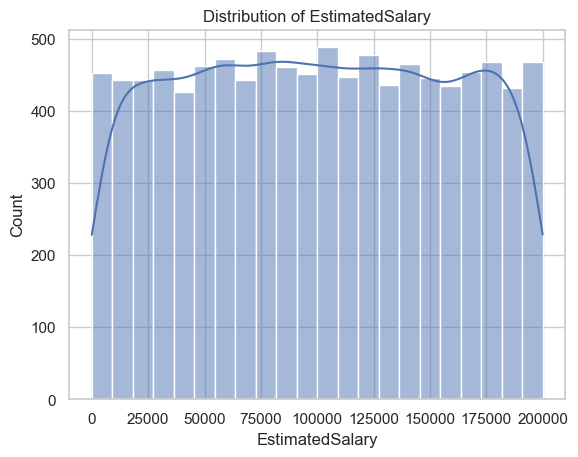

In [10]:
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

## Nhận xét:
- Phân phối của các biến giúp hiểu đặc điểm dữ liệu:
  - `Age`: thường lệch phải → nhiều khách hàng trẻ hơn
  - `Balance`: có thể có nhiều giá trị = 0 → cần chú ý
  - `EstimatedSalary`: thường phân bố khá đều
- Có thể tồn tại outlier → cần kiểm tra bằng boxplot/IQR

## 5.2. Categorical feature

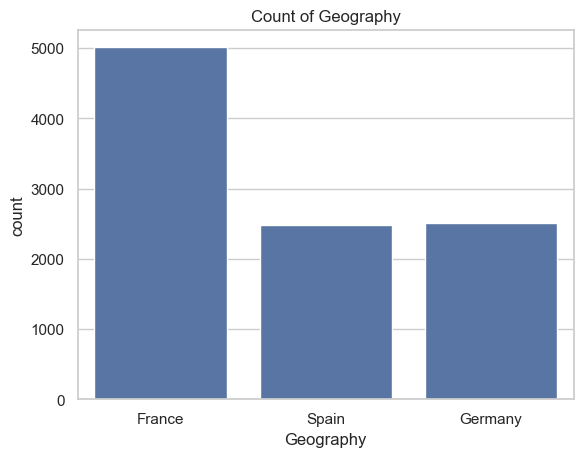

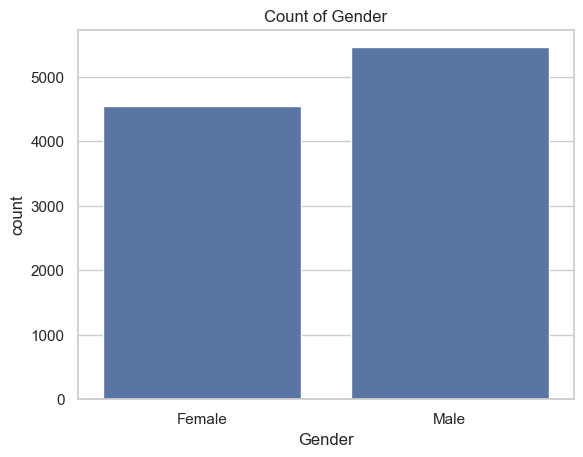

In [11]:
for col in cat_cols:
    plt.figure()
    sns.countplot(x=df[col])
    plt.title(f"Count of {col}")
    plt.show()

## Nhận xét:
- `Geography`: phân bố không đều giữa các quốc gia
- `Gender`: thường cân bằng giữa nam và nữ
- Cần kiểm tra xem nhóm nào có tỷ lệ churn cao hơn

## 5.3. Binary feature

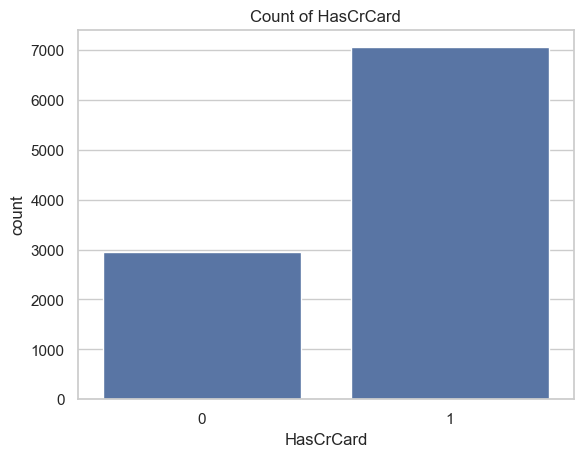

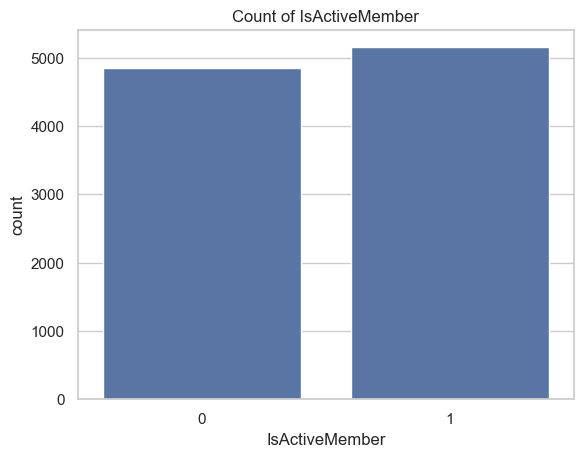

In [12]:
for col in bin_cols:
    plt.figure()
    sns.countplot(x=df[col])
    plt.title(f"Count of {col}")
    plt.show()

# 6. Outlier detection (IQR)

In [13]:
def detect_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers")

for col in num_cols:
    detect_outliers(col)

CreditScore: 15 outliers
Age: 359 outliers
Balance: 0 outliers
EstimatedSalary: 0 outliers


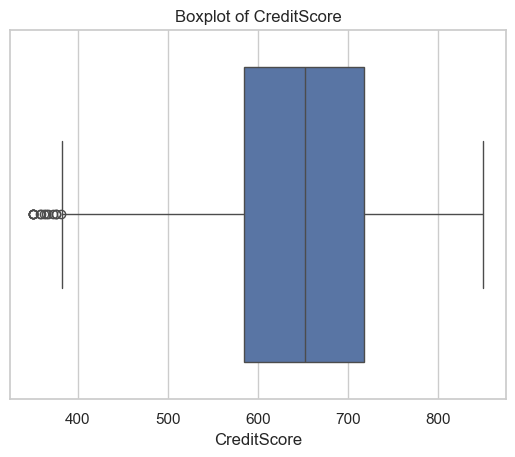

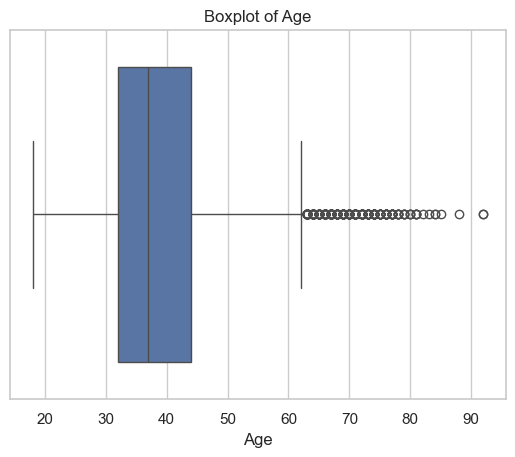

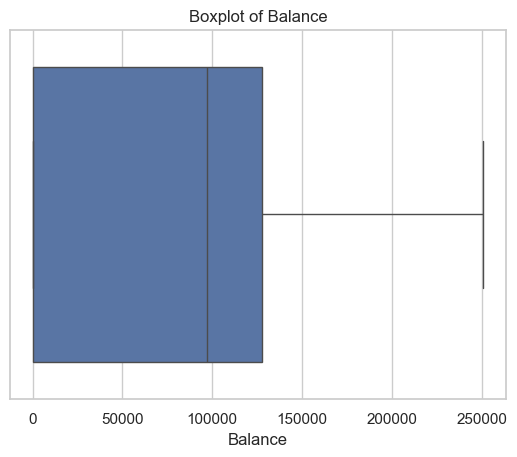

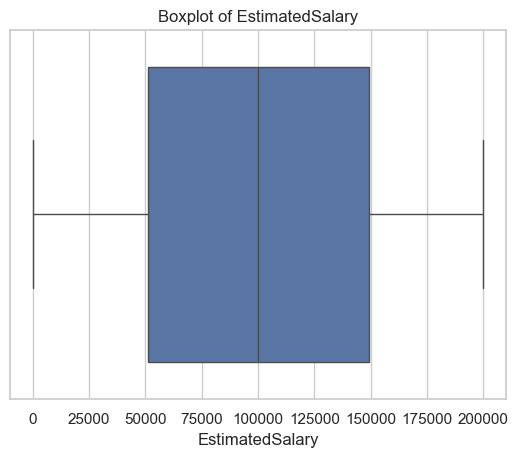

In [14]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## Nhận xét:
- Outlier xuất hiện trong các biến như:
  - `Balance`
  - `Age`
- Tuy nhiên:
  - Với mô hình tree (Random Forest, XGBoost) → không cần xử lý mạnh
  - Với mô hình tuyến tính → có thể cần scaling hoặc xử lý

→ Không nên xóa outlier vội, cần xem xét theo ngữ cảnh

# 7. Bivariate Analysis

## 7.1. Numerical vs Target

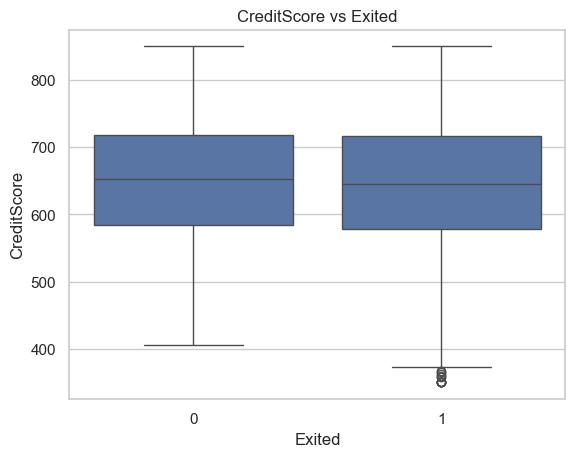

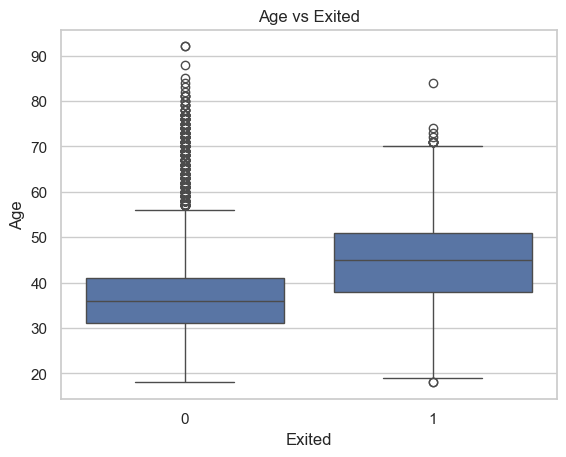

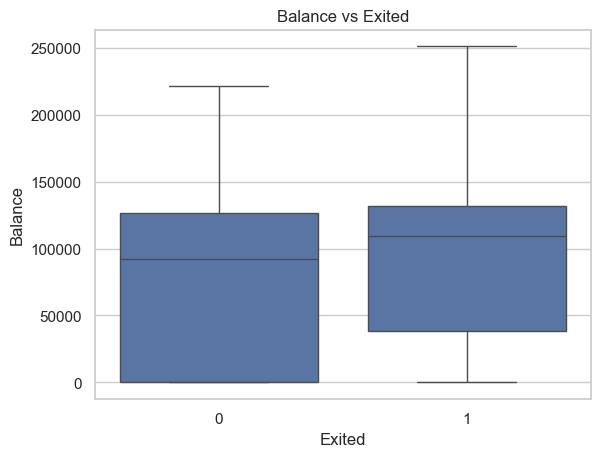

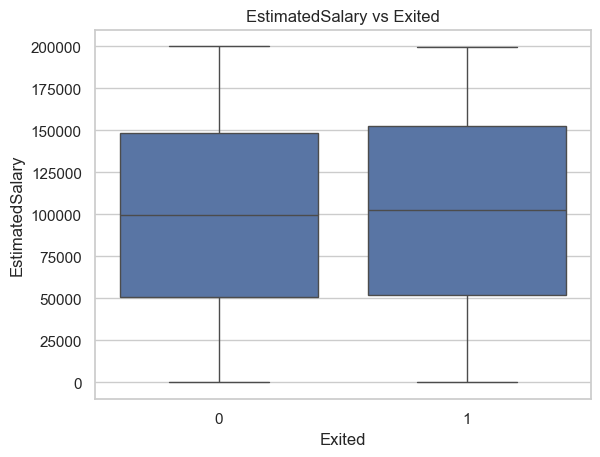

In [15]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[target], y=df[col])
    plt.title(f"{col} vs Exited")
    plt.show()

## Nhận xét:
- `Age`: khách hàng lớn tuổi có xu hướng churn cao hơn
- `Balance`: khách có số dư cao có thể dễ rời bỏ hơn
- `CreditScore`: thường không tách biệt rõ giữa 2 nhóm

→ `Age` và `Balance` là feature quan trọng

## 7.2 Categorical vs Target

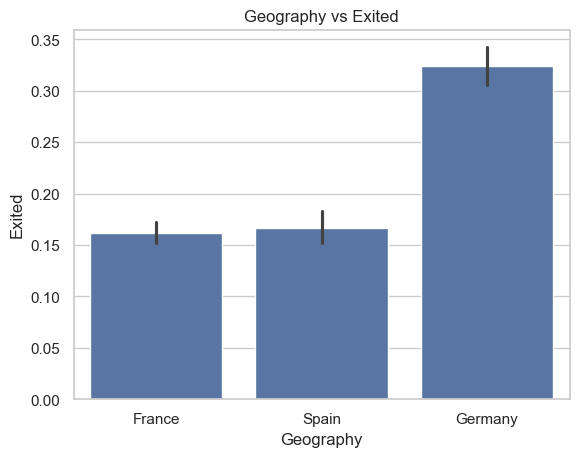

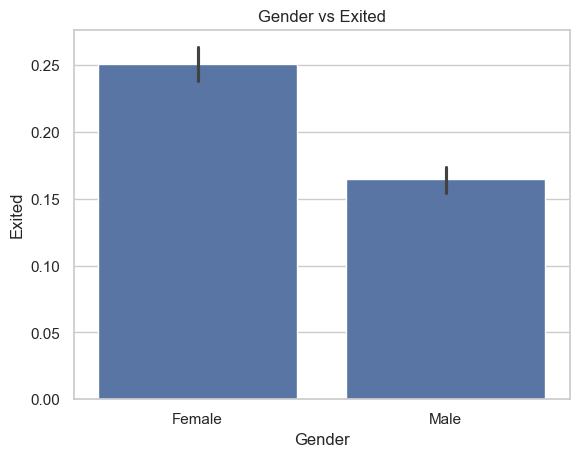

In [16]:
for col in cat_cols:
    plt.figure()
    sns.barplot(x=df[col], y=df[target])
    plt.title(f"{col} vs Exited")
    plt.show()

## Nhận xét:
- `Geography`: một số quốc gia có tỷ lệ churn cao hơn rõ rệt
- `Gender`: có thể có sự khác biệt nhẹ giữa nam và nữ

→ Geography là feature rất đáng chú ý

## 7.3 Binary vs Target

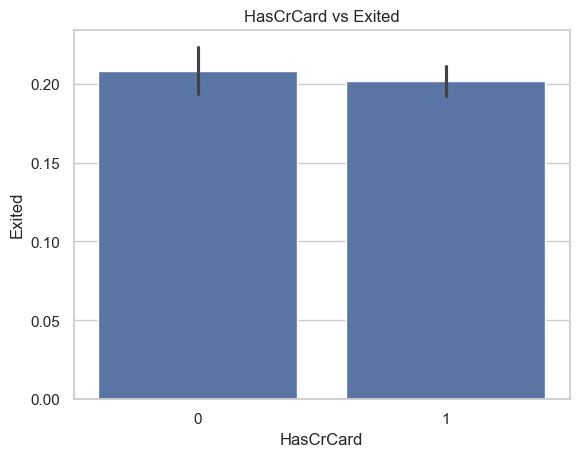

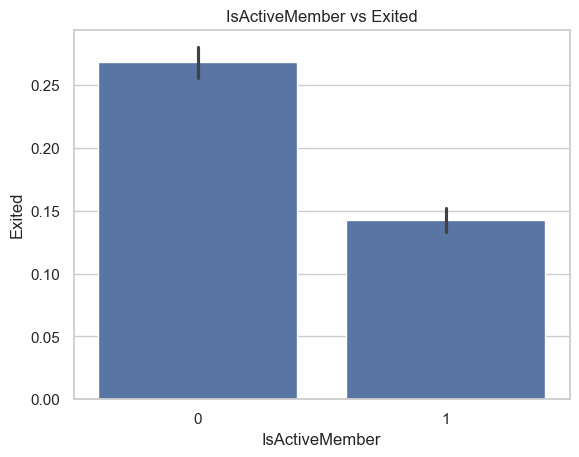

In [17]:
for col in bin_cols:
    plt.figure()
    sns.barplot(x=df[col], y=df[target])
    plt.title(f"{col} vs Exited")
    plt.show()

## Nhận xét:
- `IsActiveMember`: khách hàng không active có tỷ lệ churn cao hơn rõ rệt
- `HasCrCard`: ảnh hưởng không rõ ràng

→ `IsActiveMember` là feature quan trọng

# 8. Correlation Analysis

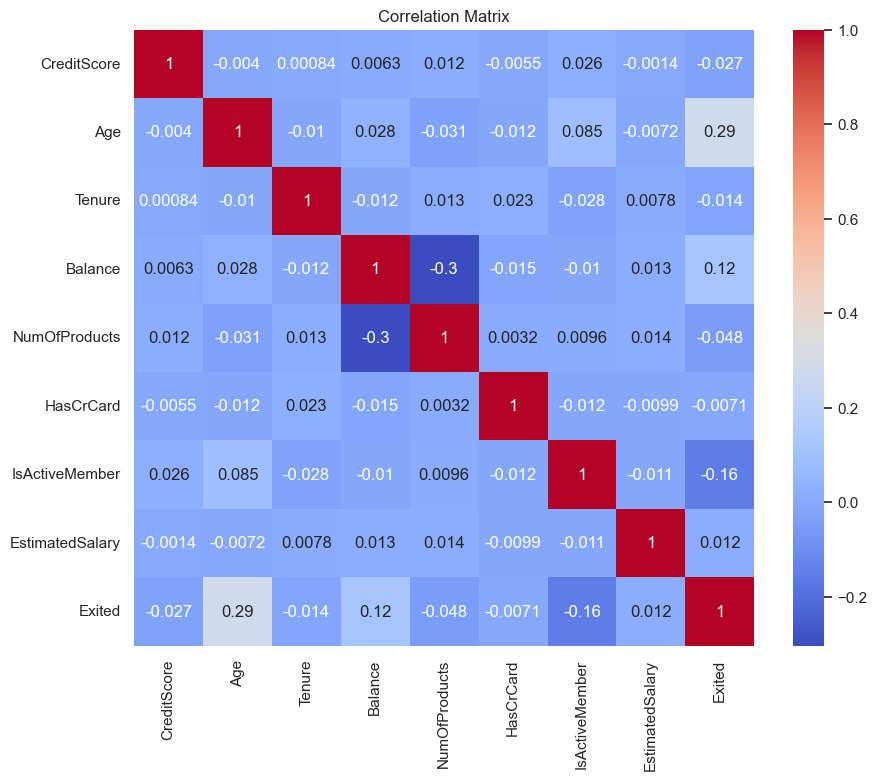

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Nhận xét:
- Không có cặp biến nào tương quan quá cao → ít nguy cơ multicollinearity
- `Age`, `Balance`, `IsActiveMember` có tương quan đáng kể với `Exited`

→ Có thể giữ lại hầu hết feature

# 9. Target analysis

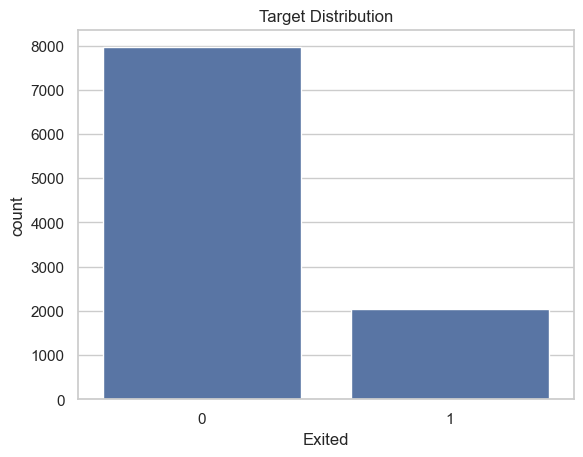

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [19]:
sns.countplot(x=df[target])
plt.title("Target Distribution")
plt.show()

df[target].value_counts(normalize=True)

## Nhận xét:
- Dữ liệu bị mất cân bằng (imbalance):
  - Số khách không churn nhiều hơn churn
- Điều này có thể làm model bias

→ Cần xử lý:
- class_weight
- hoặc SMOTE (nếu cần)

## Tổng kết EDA

- Dataset sạch, không có missing values
- Một số feature có outlier nhưng chưa cần xử lý ngay
- Các yếu tố ảnh hưởng mạnh đến churn:
  - Age
  - Balance
  - IsActiveMember
  - Geography
- Target bị imbalance → cần chú ý khi train model

# Tạo file csv mới sau khi clean

In [20]:
import pandas as pd

# 1. Bỏ các cột rác không có ý nghĩa dự đoán
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df_clean = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# 2. Tạo 3 cột Tương tác hành vi (Feature Engineering)
# df_clean['Balance_Salary_Ratio'] = df_clean['Balance'] / (df_clean['EstimatedSalary'] + 1e-6)
# df_clean['Active_CreditCard'] = df_clean['IsActiveMember'] * df_clean['HasCrCard']
# df_clean['Tenure_Age_Ratio'] = df_clean['Tenure'] / df_clean['Age']

# 3. LƯU THÀNH FILE CSV MỚI
df_clean.to_csv('../data/churn_prepared_data.csv', index=False)

print("Đã lưu thành công file 'churn_prepared_data.csv'!")
display(df_clean.head())

Đã lưu thành công file 'churn_prepared_data.csv'!


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
